In [1]:
import numpy as np
import matplotlib.pyplot as plt

P_SC   = 0.0135      # your measured per-lap safety-car probability
SC_DUR = 4

def flag_transition(f):
    if f == 0:
        return [(0, 1 - P_SC), (SC_DUR, P_SC)]
    return [(f - 1, 1.0)]

states = ['Green', 'SC-4', 'SC-3', 'SC-2', 'SC-1']
state_idx = [0, 4, 3, 2, 1]          # internal flag codes, in display order

T = np.zeros((5, 5))
for i, f in enumerate(state_idx):
    for nf, p in flag_transition(f):
        j = state_idx.index(nf)
        T[i, j] = p

print("Transition matrix T (rows = current state, cols = next state):")
print("        " + "  ".join(f"{s:>6s}" for s in states))
for i, s in enumerate(states):
    print(f"{s:>6s}  " + "  ".join(f"{T[i,j]:6.4f}" for j in range(5)))

Transition matrix T (rows = current state, cols = next state):
         Green    SC-4    SC-3    SC-2    SC-1
 Green  0.9865  0.0135  0.0000  0.0000  0.0000
  SC-4  0.0000  0.0000  1.0000  0.0000  0.0000
  SC-3  0.0000  0.0000  0.0000  1.0000  0.0000
  SC-2  0.0000  0.0000  0.0000  0.0000  1.0000
  SC-1  1.0000  0.0000  0.0000  0.0000  0.0000


In [2]:
row_sums = T.sum(axis=1)
print("Row sums (each must equal 1):", row_sums)
assert np.allclose(row_sums, 1.0), "Rows don't sum to 1 — not a valid transition matrix!"
print("Valid stochastic matrix ✓")

Row sums (each must equal 1): [1. 1. 1. 1. 1.]
Valid stochastic matrix ✓


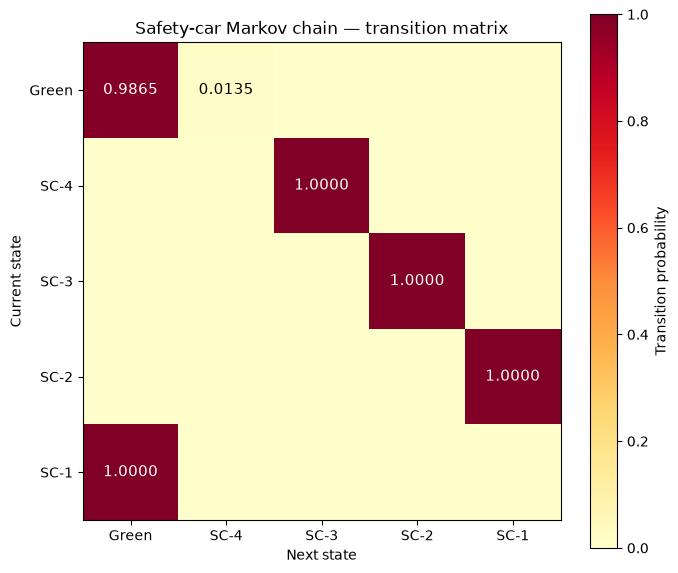

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(T, cmap='YlOrRd', vmin=0, vmax=1)

ax.set_xticks(range(5)); ax.set_xticklabels(states)
ax.set_yticks(range(5)); ax.set_yticklabels(states)
ax.set_xlabel('Next state'); ax.set_ylabel('Current state')
ax.set_title('Safety-car Markov chain — transition matrix')

for i in range(5):
    for j in range(5):
        if T[i, j] > 0:
            ax.text(j, i, f"{T[i,j]:.4f}", ha='center', va='center',
                    color='white' if T[i,j] > 0.5 else 'black', fontsize=11)

plt.colorbar(im, label='Transition probability')
plt.tight_layout()
plt.savefig('markov_transition_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

Steady-state check — distribution after 57 laps:
{'Green': np.float64(0.9488), 'SC-4': np.float64(0.0128), 'SC-3': np.float64(0.0128), 'SC-2': np.float64(0.0128), 'SC-1': np.float64(0.0128)}


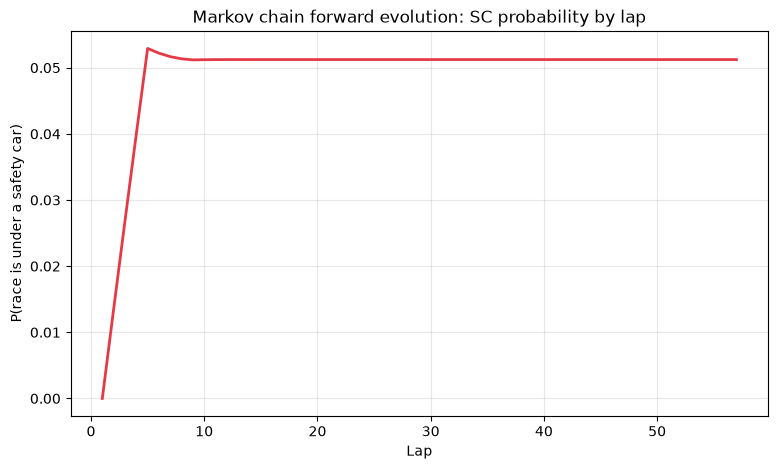

In [4]:
pi = np.array([1.0, 0, 0, 0, 0])     # lap 1: race certainly starts green

N_LAPS = 57
p_under_sc = []
for lap in range(N_LAPS):
    p_under_sc.append(1 - pi[0])      # P(in any SC state this lap)
    pi = pi @ T                        # <-- THE matrix multiplication

print(f"Steady-state check — distribution after {N_LAPS} laps:")
print({s: round(p, 4) for s, p in zip(states, pi)})

plt.figure(figsize=(9, 5))
plt.plot(range(1, N_LAPS + 1), p_under_sc, lw=2, color='#e63946')
plt.xlabel('Lap'); plt.ylabel('P(race is under a safety car)')
plt.title('Markov chain forward evolution: SC probability by lap')
plt.grid(alpha=0.3)
plt.savefig('markov_forward_evolution.png', dpi=200, bbox_inches='tight')
plt.show()

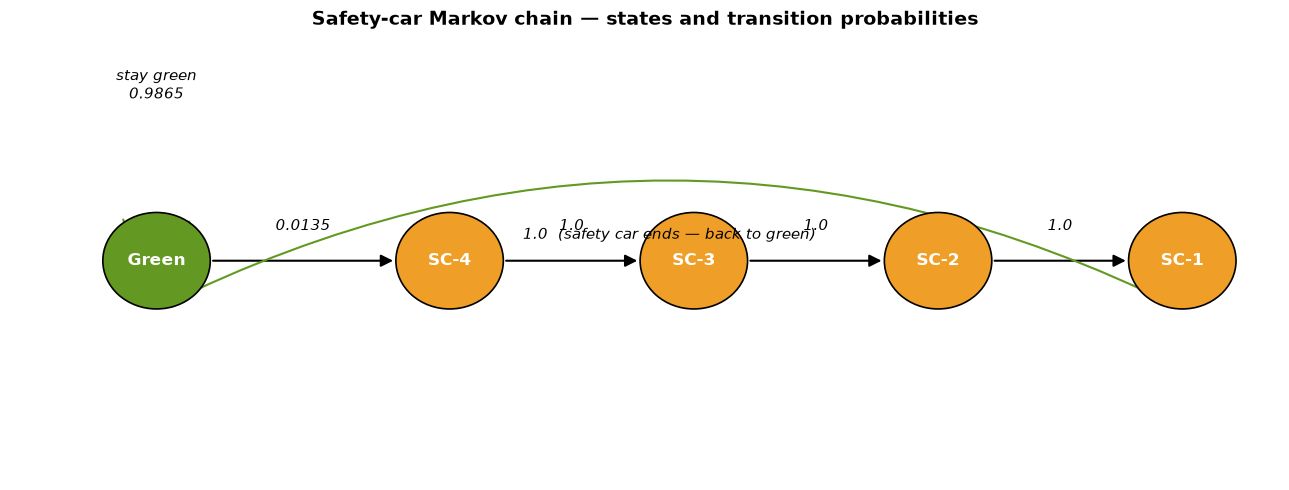

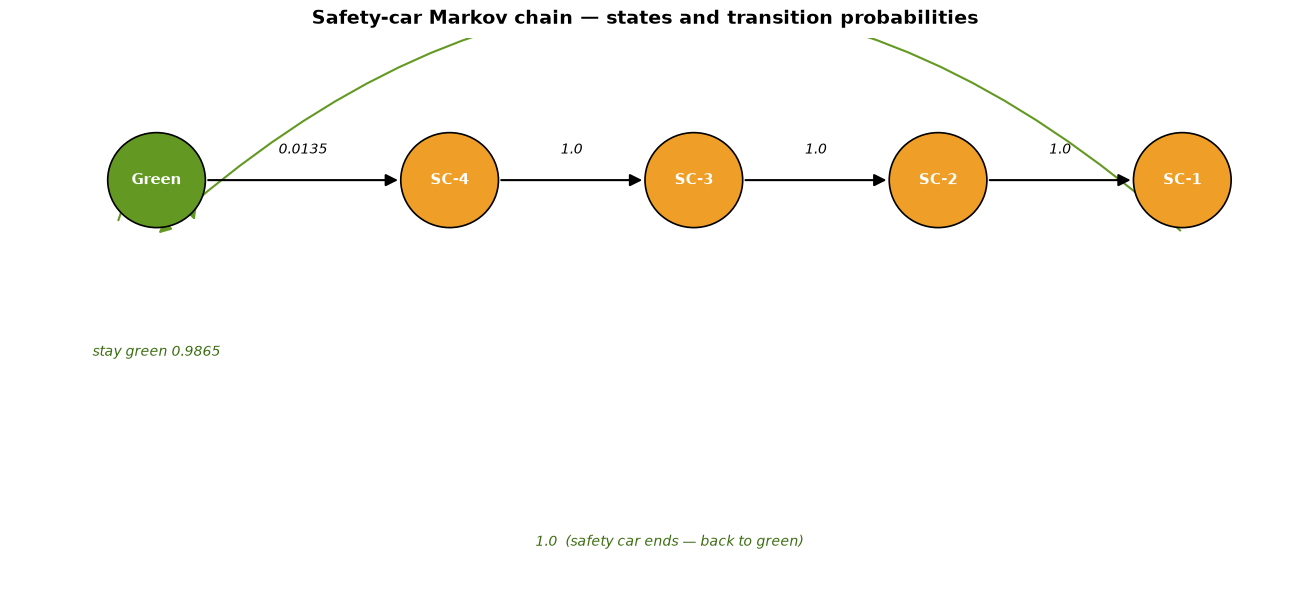

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

P_SC = 0.0135

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(-1.2, 4.5)
ax.axis('off')

pos = {'Green': (1.5, 3.0), 'SC-4': (4.5, 3.0), 'SC-3': (7.0, 3.0),
       'SC-2': (9.5, 3.0), 'SC-1': (12.0, 3.0)}
colors = {'Green': '#639922', 'SC-4': '#EF9F27', 'SC-3': '#EF9F27',
          'SC-2': '#EF9F27', 'SC-1': '#EF9F27'}

for name, (x, y) in pos.items():
    ax.add_patch(Circle((x, y), 0.5, facecolor=colors[name],
                        edgecolor='black', lw=1.2, zorder=3))
    ax.text(x, y, name, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=4)

def harrow(x1, x2, y, label):
    a = FancyArrowPatch((x1, y), (x2, y), arrowstyle='-|>',
                        mutation_scale=18, lw=1.5, color='black', zorder=2)
    ax.add_patch(a)
    ax.text((x1+x2)/2, y + 0.28, label, ha='center', fontsize=10, style='italic')

harrow(2.0, 4.0, 3.0, f'{P_SC:.4f}')
harrow(5.0, 6.5, 3.0, '1.0')
harrow(7.5, 9.0, 3.0, '1.0')
harrow(10.0, 11.5, 3.0, '1.0')

# self-loop UNDER the Green circle, tight arc
loop = FancyArrowPatch((1.1, 2.55), (1.9, 2.55),
                       connectionstyle="arc3,rad=-1.5",
                       arrowstyle='-|>', mutation_scale=16, lw=1.5,
                       color='#639922', zorder=2)
ax.add_patch(loop)
ax.text(1.5, 1.15, f'stay green {1-P_SC:.4f}', ha='center',
        fontsize=10, style='italic', color='#3B6D11')

# return arrow: SC-1 -> Green, curving lower, beneath the self-loop
ret = FancyArrowPatch((12.0, 2.45), (1.5, 2.42),
                      connectionstyle="arc3,rad=0.45",
                      arrowstyle='-|>', mutation_scale=18, lw=1.5,
                      color='#639922', zorder=1)
ax.add_patch(ret)
ax.text(6.75, -0.85, '1.0  (safety car ends — back to green)',
        ha='center', fontsize=10, style='italic', color='#3B6D11')

ax.set_title('Safety-car Markov chain — states and transition probabilities',
             fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('markov_state_diagram.png', dpi=200, bbox_inches='tight')
plt.show()

deterministic optimum = lap 22 | mean advantage = 1.75s | wins/ties = 72%


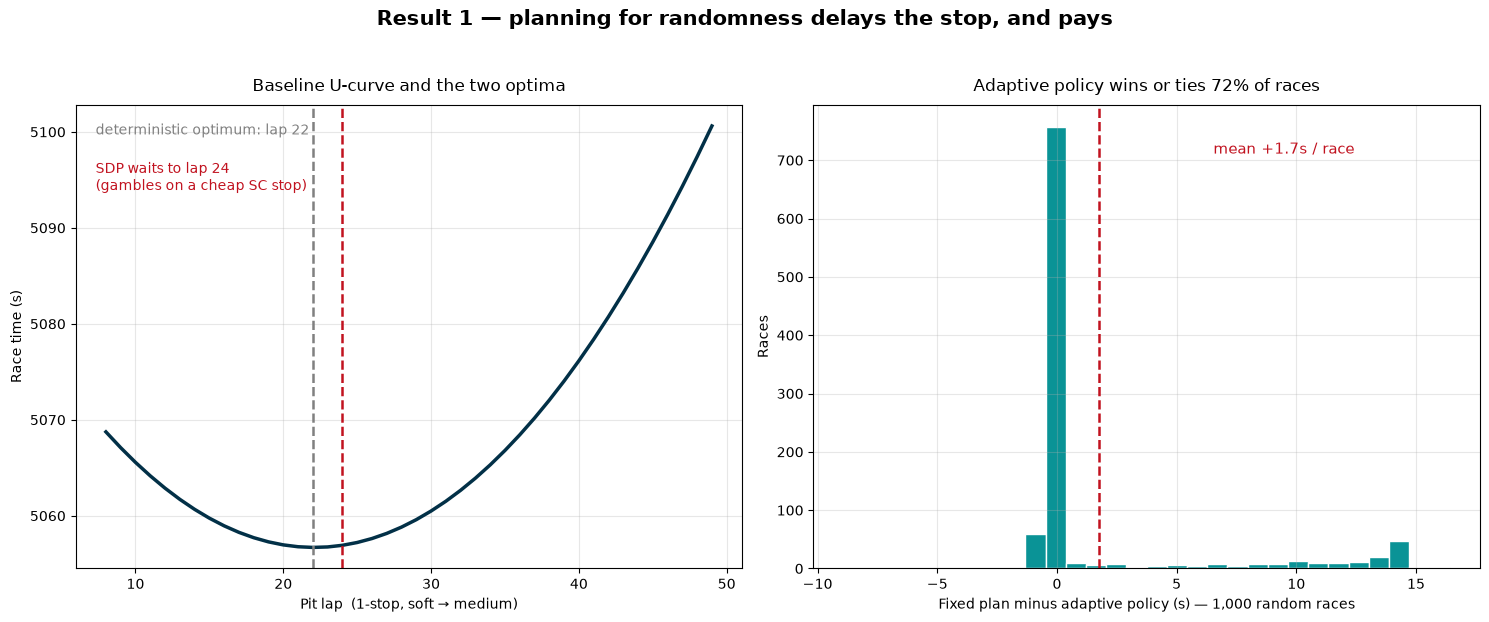

In [1]:
# ---------------------------------------------------------------
# Result 1 figure: baseline U-curve  +  adaptive-vs-fixed histogram
# (2-state geometric safety-car model, no battery layer)
# ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

deg = {'SOFT': {'base': 90.0, 'd': 0.0844},
       'MEDIUM': {'base': 90.6, 'd': 0.0369},
       'HARD': {'base': 91.2, 'd': 0.0521}}
FUEL, PIT_LOSS, PIT_SC, N_LAPS = -0.10, 26.4, 12.0, 57
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']
P_SC, Q_END, SC_LAP_TIME = 0.0135, 0.25, 140.0


def lap_time(c, a, l):
    p = deg[c]
    return p['base'] + p['d'] * a + FUEL * l


def flag_transition(f):
    # 0 = green, 1 = safety car; geometric SC duration (mean 1/Q_END laps)
    if f == 0:
        return [(0, 1 - P_SC), (1, P_SC)]
    return [(1, 1 - Q_END), (0, Q_END)]


def race_time_1stop(pit_on):
    total, lap = 0.0, 1
    for a in range(1, pit_on + 1):
        total += lap_time('SOFT', a, lap); lap += 1
    total += PIT_LOSS
    for a in range(1, N_LAPS - pit_on + 1):
        total += lap_time('MEDIUM', a, lap); lap += 1
    return total


pit_laps = list(range(8, N_LAPS - 7))
times = [race_time_1stop(L) for L in pit_laps]
L_det = pit_laps[int(np.argmin(times))]


def solve():
    NC, NA, NM, NF = 3, N_LAPS + 1, 2, 2
    INF = float('inf')
    V = np.full((N_LAPS + 2, NC, NA, NM, NF), INF)
    POL = np.full((N_LAPS + 1, NC, NA, NM, NF), -1, dtype=int)
    V[N_LAPS + 1, :, :, 1, :] = 0.0
    for n in range(N_LAPS, 0, -1):
        for ci in range(NC):
            c = COMPOUNDS[ci]
            for a in range(NA):
                for m in range(NM):
                    for f in range(NF):
                        best, ba = INF, -1
                        if f == 0:
                            if a + 1 < NA:
                                cost = lap_time(c, a + 1, n)
                                ev = sum(p * V[n + 1, ci, a + 1, m, nf] for nf, p in flag_transition(f))
                                if cost + ev < best:
                                    best, ba = cost + ev, -1
                        else:
                            cost = SC_LAP_TIME
                            ev = sum(p * V[n + 1, ci, a, m, nf] for nf, p in flag_transition(f))
                            if cost + ev < best:
                                best, ba = cost + ev, -1
                        for xi in range(NC):
                            m2 = 1 if (xi != ci or m == 1) else 0
                            if f == 0:
                                cost = lap_time(COMPOUNDS[xi], 1, n) + PIT_LOSS; a2 = 1
                            else:
                                cost = SC_LAP_TIME + PIT_SC; a2 = 0
                            ev = sum(p * V[n + 1, xi, a2, m2, nf] for nf, p in flag_transition(f))
                            if cost + ev < best:
                                best, ba = cost + ev, xi
                        V[n, ci, a, m, f] = best
                        POL[n, ci, a, m, f] = ba
    return POL


POL = solve()


def simulate(POL, flags, start='SOFT'):
    ci, a, m, total = COMPOUNDS.index(start), 0, 0, 0.0
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]; act = POL[n, ci, a, m, f]
        if act == -1:
            if f == 0:
                a += 1; total += lap_time(COMPOUNDS[ci], a, n)
            else:
                total += SC_LAP_TIME
        else:
            if act != ci or m == 1:
                m = 1
            ci = act
            if f == 0:
                a = 1; total += lap_time(COMPOUNDS[ci], a, n) + PIT_LOSS
            else:
                a = 0; total += SC_LAP_TIME + PIT_SC
    return total


def fixed_plan_time(flags, pit=L_det):
    ci, a, total = 0, 0, 0.0
    for n in range(1, N_LAPS + 1):
        f = flags[n - 1]
        if n == pit:
            ci = 1
            if f == 0:
                a = 1; total += lap_time('MEDIUM', a, n) + PIT_LOSS
            else:
                a = 0; total += SC_LAP_TIME + PIT_SC
        else:
            if f == 0:
                a += 1; total += lap_time(COMPOUNDS[ci], a, n)
            else:
                total += SC_LAP_TIME
    return total


rng = np.random.default_rng(42)


def random_flags():
    seq, f = [], 0
    for _ in range(N_LAPS):
        seq.append(f)
        if f == 0:
            f = 1 if rng.random() < P_SC else 0
        else:
            f = 0 if rng.random() < Q_END else 1
    return seq


diffs = np.array([fixed_plan_time(fl) - simulate(POL, fl)
                  for fl in (random_flags() for _ in range(1000))])
mean_adv = diffs.mean()
winpct = (diffs >= -1e-9).mean() * 100
print(f"deterministic optimum = lap {L_det} | mean advantage = {mean_adv:.2f}s | wins/ties = {winpct:.0f}%")

# ---- figure (spacious layout so nothing is cut off) ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Result 1 — planning for randomness delays the stop, and pays',
             fontsize=15, fontweight='bold', y=1.03)

ax1.plot(pit_laps, times, lw=2.5, color='#023047')
ax1.axvline(L_det, color='gray', ls='--', lw=1.8)
ax1.axvline(24, color='#c1121f', ls='--', lw=1.8)
ax1.set_title('Baseline U-curve and the two optima', fontsize=12, pad=10)
ax1.set_xlabel('Pit lap  (1-stop, soft \u2192 medium)')
ax1.set_ylabel('Race time (s)')
ax1.grid(alpha=0.3)
ax1.text(0.03, 0.96, f'deterministic optimum: lap {L_det}',
         transform=ax1.transAxes, color='gray', fontsize=10, va='top')
ax1.text(0.03, 0.88, 'SDP waits to lap 24\n(gambles on a cheap SC stop)',
         transform=ax1.transAxes, color='#c1121f', fontsize=10, va='top')

ax2.hist(diffs, bins=30, color='#0a9396', edgecolor='white')
ax2.axvline(mean_adv, color='#c1121f', ls='--', lw=1.8)
ax2.text(0.60, 0.92, f'mean +{mean_adv:.1f}s / race',
         transform=ax2.transAxes, color='#c1121f', fontsize=11, va='top')
ax2.set_title(f'Adaptive policy wins or ties {winpct:.0f}% of races', fontsize=12, pad=10)
ax2.set_xlabel('Fixed plan minus adaptive policy (s) \u2014 1,000 random races')
ax2.set_ylabel('Races')
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig('result1_baseline_adaptive.png', dpi=200, bbox_inches='tight')
plt.show()